<img src="https://github.com/Ch3ddarr/DSB-Unit-03/blob/main/assets/ga-logo.png?raw=1" style="float: left; margin: 20px; height: 55px">

# Introduction to Simple Linear Regression

---

### About
An introduction to Linear Regression: what it is, how it works, and how to run a model using `scikit-learn`.

### Learning Objectives
- Describe modeling.
- Calculate mean squared error.
- State the assumptions of a linear regression model.
- Be able to interpret the coefficients of a linear regression model.
- Identify the difference between simple and multiple linear regression.
- Fit, generate predictions from, and evaluate a linear regression model in `sklearn`, and maybe in `statsmodels`.

### Notebook Guide

Part I. **Simple Linear Regression**
- Introduction to Modeling (see slides)
- Baseline Prediction
- OLS regression model in scikit-learn
- Interpreting SLR Model
- Assumptions of SLR Model

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Part I: Simple Linear Regression

When you have 1 predictor variable you are doing _simple linear regression_.

## The Data
Data source: [here](https://www.rdocumentation.org/packages/fpp2/versions/2.3/topics/elecdemand)

The data consist of electricity demand for Victoria, Australia every half-hour in 2014. We have three columns:

* Total electricity demand (in gigawatts)
* Whether or not it is a workday (0/1)
* Temperature (Celsius)

In [45]:
elec = pd.read_csv('https://raw.githubusercontent.com/Ch3ddarr/DSB-Unit-03/refs/heads/main/data/elecdemand.csv')

In [46]:
elec.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17520 entries, 0 to 17519
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   demand   17520 non-null  float64
 1   workday  17520 non-null  int64  
 2   temp     17520 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 410.8 KB


In [47]:
elec['workday'].unique()

array([0, 1])

In [48]:
elec['demand'].describe()

,demand
count,17520.000000
mean,4.609947
std,0.877780
min,2.857946
25%,3.927284
50%,4.596284
75%,5.159062
max,9.345004


In [49]:
elec['temp'].describe()

,temp
count,17520.000000
mean,16.505417
std,5.613729
min,1.500000
25%,12.600000
50%,15.800000
75%,19.400000
max,43.200000


In [50]:
# For this exercise only, we'll limit our focus to only days in which it was at least 20 degrees Celsius (68 F)
elec15 = elec[elec['temp']>=15]

<Axes: xlabel='temp', ylabel='demand'>

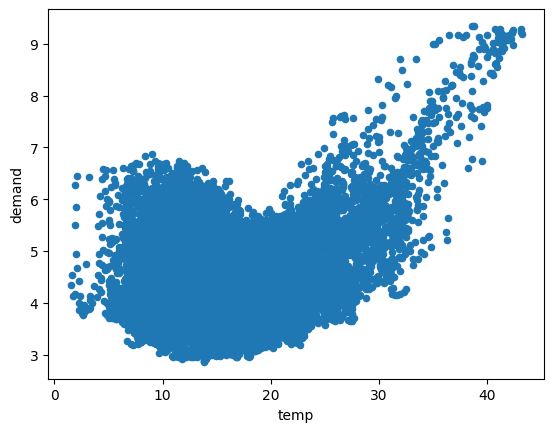

In [51]:
# Plot temperature vs. demand
elec.plot(
    kind = 'scatter',
    x='temp',
    y='demand'
    )

<Axes: xlabel='temp', ylabel='demand'>

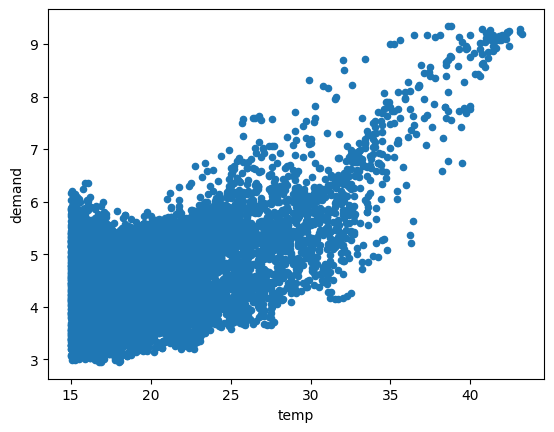

In [52]:
elec15.plot(
    kind = 'scatter',
    x='temp',
    y='demand'
    )

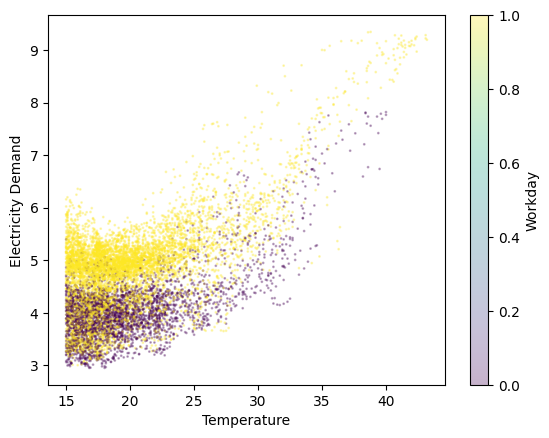

In [53]:
# using matplotlib

plt.scatter(
    elec15['temp'],
    elec15['demand'],
    s=1,
    alpha=0.3,
    c=elec15['workday']
)

plt.xlabel('Temperature')
plt.ylabel('Electricity Demand')
plt.colorbar(label='Workday');

## The Null model

<details><summary>If we had to guess the demand for any new temperature what would you pick?</summary>
We don't have much information yet, so probably just the mean!
</details>

In [54]:
elec15['demand'].mean()

4.622494812629097

## How could we improve our model?

<details><summary>If we were to draw a straight line that fit the points the best, what would that look like?</summary>
<img src="https://github.com/Ch3ddarr/DSB-Unit-03/blob/main/images/ols.png?raw=1", style="height: 350px">
</details>

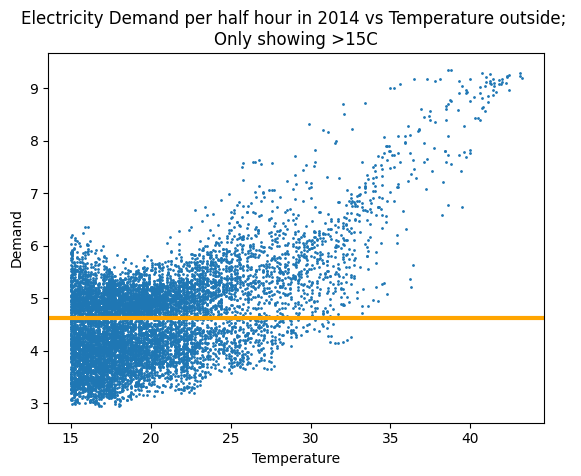

In [55]:
plt.scatter(elec15['temp'], elec15['demand'], s=1)
plt.axhline(elec15['demand'].mean(), color = 'orange', lw=3)
plt.xlabel('Temperature')
plt.ylabel('Demand')
plt.title('Electricity Demand per half hour in 2014 vs Temperature outside; \nOnly showing >15C');

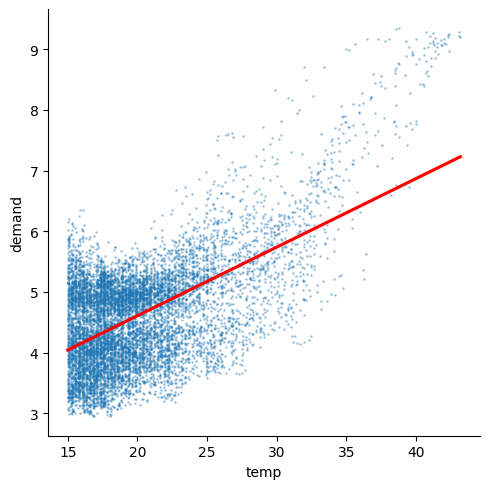

In [56]:
sns.lmplot(x='temp', y='demand', data=elec15, ci=None,
           scatter_kws = {'s':1, 'alpha':0.3},
           line_kws={'color':'red'}
           );

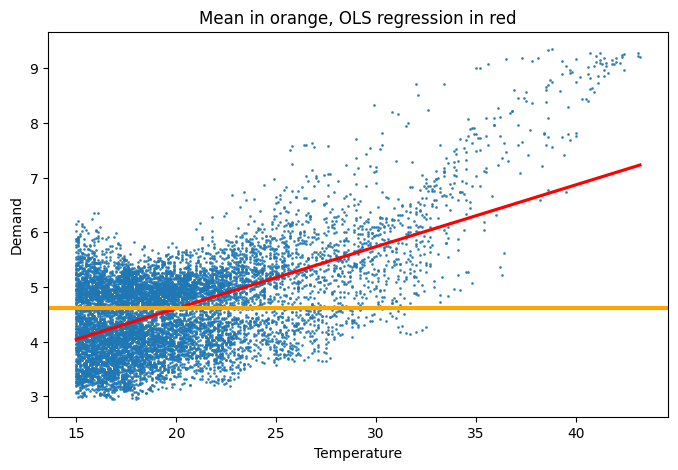

In [57]:
plt.figure(figsize=(8,5))
sns.regplot(
    x='temp',
    y='demand',
    data=elec15,
    ci=None,
    scatter_kws = {'s': 1},
    line_kws = {'color': 'red'}
    )
plt.axhline(elec15['demand'].mean(), color='orange', lw=3)
plt.xlabel('Temperature')
plt.ylabel('Demand')
plt.title('Mean in orange, OLS regression in red');

**Is that line better fit the data than our old line that was just the mean?**

Looks like it. We'll discuss formal evaluation metrics in a bit.

## Lines

This was the equation I learned for a line. Look familiar?
$$ y = mx + b$$
In data science it gets changed to

$$ y = \beta_0 + \beta_1 x_1 $$

### Errors

Our model isn't going to be perfect. The things our model doesn't capture are errors and denoted by $\epsilon$ (epsilon).

$$ y = \beta_0 + \beta_1 x_1 + \epsilon $$

### OLS Regression Modeling

We have _x_ and we have _y_. That's our data.

Our model is trying to figure out the best betas.

$$ \hat y = \hat \beta_0 + \hat \beta_1 x_1 $$


$\hat \beta_0$ is the y-intercept that our model learns. The point where the line crosses the y-axis.

$\hat \beta_1$ is the coefficient that we multiply by our $x_1$ variable. It's the slope. For every 1 unit it change in $x_1$, y increases by the value of $\beta1$.

$y$ is the ground truth of our target variable.


$$ \hat y =  \hat\beta_0 +  \hat\beta_1 x_1 $$

When we have a model that has been fit with the data the betas have been computed. We can plug in a new x value and solve for $\hat y$.

#### $\hat y$ is a prediction! 🎉

---
## OLS regression model in `scikit-learn`.

### Step 1: Assemble our predictor variables (X) and our target (y)

 We need an X matrix that is n-by-p.
- n = rows
- p = features

A feature just means a predictor column.

In the simple linear regression case, p = 1. We have one feature ($x_1$). Usually you'll have more than 1 feature.

In [58]:
# Step 1: Assemble our X and y variables

# We need an X matrix that is n-by-p (in this case, p = 1)
X = elec15[['temp']]

In [59]:
type(X)

pandas.core.frame.DataFrame

#### Why did we make X a `DataFrame`?
`scikit-learn` expects a two dimensional object. Usually we have more than one predictor variable.

y is the outcome variable

In [60]:
# We need a y vector that is length n
y = elec15['demand']

In [61]:
y.shape

(9919,)

#### Why is the target a `Series` or 1D numpy array?

`scikit-learn` supervised learning estimators are expecting a single output column. They predict one value for each observation, generally.

### Step 2: Instantiate the model

In [62]:
# Step 2: Instantiate the model
lr = LinearRegression()

### Step 3: Fit the model

In [63]:
# Step 3: Fit the model
lr.fit(X,y)

LinearRegression()

### Step 4: Check out and interpret our model weights

In [64]:
# Take a peek at the model coefficient and intercept
print(f'b0 is: {lr.intercept_}')
print(f'b1 is: {lr.coef_}')

b0 is: 2.3463021186002933
b1 is: [ 0.11302131]


We now have the following model of reality:

$$\hat{d} = 2.32 + 0.11t$$

#### Interpretation of coefficients

In general, we can interpret our slope as having the following impact:
> For every 1 unit increase in $x_i$, we expect $y$ to increase by $\beta_i$.

<details><summary><font style = 'color:green'>How would we interpret the slope for our model?</font></summary>
For every 1 degree increase in temperature, we would expect 0.11 more gigawatts of electricty to be demanded.
</details>

#### Interpretation of our y-intercept. Does it make sense?

When it is zero degrees Celsius, we expect 2.32 gigawatts of electricity to be demanded. Ordinarily, this _would_ make sense, however, we have no data near this value (remember, we removed lots for the purpose of this exercse) and would want to avoid **extrapolation**.

### Step 5: Make predictions

If we had new data points for temperature we could pass it to the `predict` method to generate price predictions.

We don't have any new data, so let's just see what predictions our model would have made. This is the same as saying "Find the x value for a prediction on the plot and go up to our line. That value for y is our prediction."

We do this for all the x values.

In [65]:
# Make predictions
y_predict = lr.predict(X)

In [66]:
type(y_predict)

numpy.ndarray

In [85]:
list(y_predict)[0]

4.4032899849829494

In [68]:
np.set_printoptions(legacy='1.13')

In [86]:
list(y_predict)[0]

4.4032899849829494

#### Why don't we pass `y`?

We are predicting y.

In [70]:
elec15['demand'].mean()

4.622494812629097

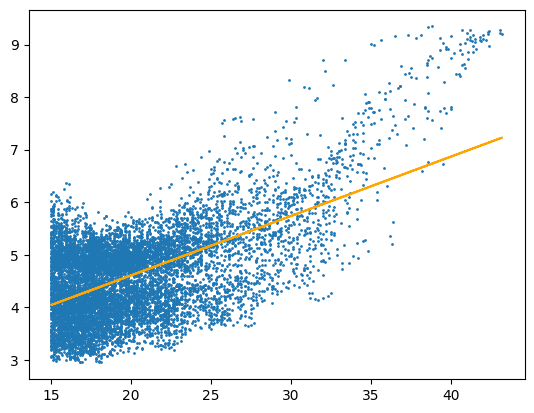

In [71]:
# We can plot them, too!
plt.scatter(elec15["temp"], elec15["demand"], s=1)
plt.plot(elec15['temp'], y_predict, color='orange')

---

To the slides!

---

### Step 6: Evaluation

We now want to see how good a job our model does at predicting demand. **Mean squared error** is a popular scoring metric.

Lower is better. That's the case whenever "error" is in the metric name.

$$ MSE = \frac{1}{n} \sum (y_i - \hat{y}_i)^2 = \frac{1}{n} \sum e_i^2 $$

#### MSE by hand:

In [87]:
# Create residuals (aka errors): (y - y_hat)
residuals = y - y_predict
residuals

,demand
0,-0.488643
1,-0.696834
2,-0.837938
3,-0.905915
4,-0.984237
...,...
17515,-0.621944
17516,-0.539684
17517,-0.469552
17518,-0.097812


In [88]:
# Compute the MSE
mse = np.mean(residuals**2)
print(mse)

0.508089276896


#### How does that model compare to our null model?

In [89]:
# Create the predictions for the "null model"
y_bar = y.mean()
y_bar

4.622494812629097

In [91]:
# The null MSE
null_mse = np.mean((y - y_bar)**2)
null_mse

0.77812292155379814

<details><summary>Which model fits the data better?</summary>
The OLS model has lower error.
</details>

Another popular regression metric is the $R^2$, which is defined as:

$$R^2 = 1 - \frac{\text{SSE}}{\text{Null SSE}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

The $R^2$, or **coefficient of determination**, is the proportion of variability in $y$ we can explain with $x$.

In [96]:
1 - (mse / null_mse)

0.34703211687759417

In [95]:
# The R2
r2 = metrics.r2_score(y, y_predict)
r2

0.34703211687759417

#### Interpret $R^2$

35.2% of the variability in electricity demand can be explained by temperature.

We don't have to calculate these metrics by hand. `sklearn` can do it for us!

In [97]:
# MSE
metrics.mean_squared_error(y, y_predict)

0.5080892768960055

In [98]:
# RMSE
metrics.root_mean_squared_error(y, y_predict)

0.7128038137496218

In [99]:
# Can compute R2 from metrics...
metrics.r2_score(y, y_predict)

0.34703211687759417

In [100]:
# ... or directly from the model...
lr.score(X,y)

0.34703211687759417

### You made your first Linear Regression Model 🎉

---

To the slides!

---

## LINE Assumptions
Let's check em!

In [81]:
# L - Linearity


<details><summary>Does this pass our L assumption?</summary>
It's definitely a little curved, but this looks okay.
</details>

In [82]:
# I - Independence

<details><summary>Does this pass our I assumption?</summary>
Yes, by assumption.
</details>

In [83]:
# N - Normality of errors


<details><summary>Does this pass our N assumption?</summary>
Just like with the Linearity assumption, this isn't great, but we might be able to get away with it.
</details>

In [84]:
# E - Equal variance of errors


<details><summary>Does this pass our E assumption?</summary>
I'm gonna go with no on this one...
</details>